In [ ]:
import requests
import os

# GeoJSON oficial de localidades — Datos Abiertos Bogotá
url = "https://datosabiertos.bogota.gov.co/dataset/7b8fb61e-2514-4969-9090-97e4831c71db/resource/de8e2a87-5b48-4e5f-9b25-9e7ae3f00bb0/download/loca.geojson"

ruta_geo = r"C:\Users\kenpa\OneDrive\Desktop\FORMACION\colombia-mercado-inmobiliario\data\external\bogota"
destino = os.path.join(ruta_geo, "localidades_bogota.geojson")

print("Descargando localidades de Bogotá...")
try:
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    with open(destino, "w", encoding="utf-8") as f:
        f.write(r.text)
    print(f"✓ Guardado: {destino}")
    print(f"  Tamaño: {os.path.getsize(destino)/1024:.1f} KB")
except Exception as e:
    print(f"✗ Error: {e}")
    print("  → Descarga manual en el siguiente paso")

In [2]:
import geopandas as gpd
import os

ruta_geo = r"C:\Users\kenpa\OneDrive\Desktop\FORMACION\colombia-mercado-inmobiliario\data\external\bogota"

# Cargar localidades
localidades = gpd.read_file(
    os.path.join(ruta_geo, "localidad_registro_social.gpkg"),
    engine="pyogrio"
)

print(f"Localidades cargadas: {len(localidades)}")
print(f"CRS: {localidades.crs}")
print(f"Columnas: {localidades.columns.tolist()}")
print()
print(localidades.drop(columns="geometry").head(5).to_string())

Localidades cargadas: 20
CRS: EPSG:4686
Columnas: ['objectid', 'locnombre', 'loccodigo', 'locarea', 'total_homb', 'total_muje', 'total_sind', 'total_edad', 'total_ed_1', 'total_ed_2', 'total_ed_3', 'total_ed_4', 'total_ed_5', 'total_ed_6', 'total_disc', 'total_di_1', 'total_di_2', 'total_di_3', 'total_di_4', 'total_di_5', 'total_di_6', 'total_di_7', 'total_di_8', 'total_di_9', 'total_etni', 'total_et_1', 'total_et_2', 'total_et_3', 'total_et_4', 'total_et_5', 'total_et_6', 'total_et_7', 'total_reac', 'total_mica', 'total_ofer', 'total_miah', 'total_mv_h', 'total_mv_1', 'total_mv_v', 'total_vivi', 'total_pers', 'st_area_sh', 'st_length_', 'geometry']

   objectid      locnombre loccodigo       locarea  total_homb  total_muje  total_sind  total_edad  total_ed_1  total_ed_2  total_ed_3  total_ed_4  total_ed_5  total_ed_6  total_disc  total_di_1  total_di_2  total_di_3  total_di_4  total_di_5  total_di_6  total_di_7  total_di_8  total_di_9  total_etni  total_et_1  total_et_2  total_et_3  t

In [3]:
import geopandas as gpd
import pandas as pd
import os

RUTA_PROCESSED = r"C:\Users\kenpa\OneDrive\Desktop\FORMACION\colombia-mercado-inmobiliario\data\processed"
RUTA_GEO = r"C:\Users\kenpa\OneDrive\Desktop\FORMACION\colombia-mercado-inmobiliario\data\external\bogota"

# ── 1. Cargar dataset procesado del notebook 01 ───────────────
gdf = gpd.read_file(
    os.path.join(RUTA_PROCESSED, "bogota_valor_ref_unificado.gpkg"),
    engine="pyogrio"
)
print(f"✅ Valor referencia cargado: {len(gdf):,} registros | CRS: {gdf.crs}")

# ── 2. Cargar localidades ─────────────────────────────────────
# Ajusta el nombre del archivo .gpkg que descargaste
localidades = gpd.read_file(
    os.path.join(RUTA_GEO, "localidades_bogota.gpkg"),  # ← cambia si el nombre es diferente
    engine="pyogrio"
)

# Seleccionar solo columnas útiles para el join
cols_localidad = [
    "locnombre", "loccodigo", "locarea",
    "total_homb", "total_muje", "total_pers",
    "total_vivi", "geometry"
]
localidades = localidades[cols_localidad].copy()
localidades.columns = [
    "localidad", "cod_localidad", "area_localidad",
    "total_hombres", "total_mujeres", "total_personas",
    "total_viviendas", "geometry"
]
print(f"✅ Localidades cargadas: {len(localidades)} | CRS: {localidades.crs}")
print(f"  Localidades: {sorted(localidades['localidad'].tolist())}")

✅ Valor referencia cargado: 125,003 registros | CRS: EPSG:4326
✅ Localidades cargadas: 20 | CRS: EPSG:4686
  Localidades: ['ANTONIO NARIÑO', 'BARRIOS UNIDOS', 'BOSA', 'CANDELARIA', 'CHAPINERO', 'CIUDAD BOLIVAR', 'ENGATIVA', 'FONTIBON', 'KENNEDY', 'LOS MARTIRES', 'PUENTE ARANDA', 'RAFAEL URIBE URIBE', 'SAN CRISTOBAL', 'SANTA FE', 'SUBA', 'SUMAPAZ', 'TEUSAQUILLO', 'TUNJUELITO', 'USAQUEN', 'USME']


✅

In [4]:
# ── 3. Alinear CRS — todo a EPSG:4326 ────────────────────────
print(f"CRS valor referencia : {gdf.crs}")
print(f"CRS localidades      : {localidades.crs}")

if localidades.crs != gdf.crs:
    localidades = localidades.to_crs(gdf.crs)
    print(f"✅ Localidades reproyectadas a {gdf.crs}")

# Verificar que ahora coinciden
assert gdf.crs == localidades.crs, "CRS aún no coinciden"
print("✅ CRS alineados correctamente")

CRS valor referencia : EPSG:4326
CRS localidades      : EPSG:4686
✅ Localidades reproyectadas a EPSG:4326
✅ CRS alineados correctamente


In [5]:
# ── 4. Spatial Join — asignar localidad a cada manzana ───────
print("Ejecutando spatial join...")

gdf_join = gpd.sjoin(
    gdf,                          # manzanas con valor m²
    localidades,                  # polígonos de localidades
    how="left",                   # conservar todas las manzanas
    predicate="within"            # manzana dentro de localidad
)

# Limpiar columna index_right que genera el sjoin
gdf_join = gdf_join.drop(columns=["index_right"], errors="ignore")

# Verificar cobertura del join
sin_localidad = gdf_join["localidad"].isna().sum()
con_localidad = gdf_join["localidad"].notna().sum()
total = len(gdf_join)

print(f"\n{'='*45}")
print(f"RESULTADO DEL SPATIAL JOIN")
print(f"{'='*45}")
print(f"  Total manzanas   : {total:,}")
print(f"  Con localidad    : {con_localidad:,}  ({con_localidad/total*100:.1f}%)")
print(f"  Sin localidad    : {sin_localidad:,}  ({sin_localidad/total*100:.1f}%)")
print(f"  Años incluidos   : {sorted(gdf_join['año'].unique())}")

Ejecutando spatial join...

RESULTADO DEL SPATIAL JOIN
  Total manzanas   : 125,003
  Con localidad    : 124,250  (99.4%)
  Sin localidad    : 753  (0.6%)
  Años incluidos   : [2021, 2022, 2024]


In [7]:
# ── 5. KPI #2 — Valor mediano por localidad y año ────────────
kpi2 = (
    gdf_join
    .groupby(["localidad", "año"])["valor_ref_m2"]
    .agg(
        mediana="median",
        media="mean",
        manzanas="count",
        valor_min="min",
        valor_max="max"
    )
    .reset_index()
)

# Calcular variación 2021 → 2024 por localidad
pivot = kpi2.pivot_table(
    index="localidad",
    columns="año",
    values="mediana"
).reset_index()
pivot.columns = ["localidad", "med_2021", "med_2022", "med_2024"]
pivot["var_pct_2021_2024"] = ((pivot["med_2024"] - pivot["med_2021"]) / pivot["med_2021"] * 100).round(1)
pivot = pivot.sort_values("var_pct_2021_2024", ascending=False)

print("\nKPI #2 — Variación del valor mediano por localidad (2021→2024)")
print("=" * 65)
print(f"{'Localidad':<25} {'2021':>10} {'2024':>10} {'🔼%':>8}")
print("-" * 65)
for _, row in pivot.iterrows():
    if pd.notna(row["med_2021"]) and pd.notna(row["med_2024"]):
        print(f"  {row['localidad']:<23} ${row['med_2021']/1e6:>7.2f}M  ${row['med_2024']/1e6:>7.2f}M  {row['var_pct_2021_2024']:>+6.1f}%")

# ── 6. Guardar ────────────────────────────────────────────────
gdf_join.to_file(
    os.path.join(RUTA_PROCESSED, "bogota_valor_localidades.gpkg"),
    driver="GPKG", engine="pyogrio"
)
kpi2.to_csv(
    os.path.join(RUTA_PROCESSED, "kpi2_valor_por_localidad.csv"),
    index=False, encoding="utf-8"
)
print(f"\n✅ Archivos guardados en /processed")


KPI #2 — Variación del valor mediano por localidad (2021→2024)
Localidad                       2021       2024       🔼%
-----------------------------------------------------------------
  CANDELARIA              $   2.00M  $   2.70M   +35.0%
  SAN CRISTOBAL           $   0.88M  $   1.07M   +21.6%
  CIUDAD BOLIVAR          $   0.68M  $   0.82M   +21.2%
  RAFAEL URIBE URIBE      $   1.50M  $   1.80M   +20.0%
  FONTIBON                $   1.95M  $   2.33M   +19.5%
  ANTONIO NARIÑO          $   2.36M  $   2.82M   +19.4%
  KENNEDY                 $   2.10M  $   2.48M   +18.1%
  BOSA                    $   1.65M  $   1.90M   +15.2%
  SUBA                    $   2.31M  $   2.66M   +14.9%
  LOS MARTIRES            $   2.55M  $   2.92M   +14.5%
  TUNJUELITO              $   1.88M  $   2.15M   +14.4%
  PUENTE ARANDA           $   2.60M  $   2.97M   +14.2%
  BARRIOS UNIDOS          $   3.00M  $   3.40M   +13.3%
  ENGATIVA                $   2.65M  $   3.00M   +13.2%
  USME                    $  

🔼

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


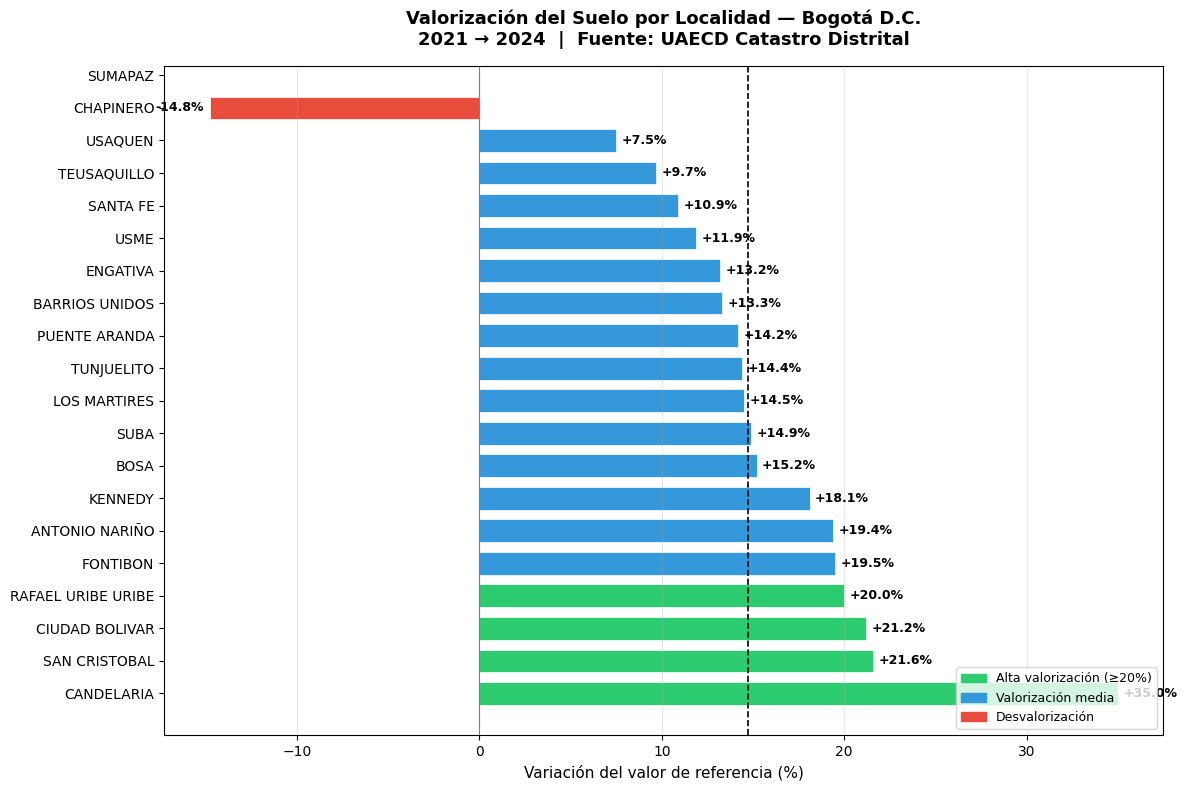

✅ Gráfica 03 guardada


In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import os

RUTA_FIGURES = r"C:\Users\kenpa\OneDrive\Desktop\FORMACION\colombia-mercado-inmobiliario\reports\figures"
os.makedirs(RUTA_FIGURES, exist_ok=True)

# ── Gráfica 1: Ranking de valorización por localidad ─────────
fig, ax = plt.subplots(figsize=(12, 8))

colores = ["#E74C3C" if v < 0 else "#2ECC71" if v >= 20 else "#3498DB"
           for v in pivot["var_pct_2021_2024"]]

bars = ax.barh(
    pivot["localidad"],
    pivot["var_pct_2021_2024"],
    color=colores, edgecolor="white", linewidth=0.5, height=0.7
)

# Etiquetas de valor
for bar, val in zip(bars, pivot["var_pct_2021_2024"]):
    x = bar.get_width()
    ax.text(x + (0.3 if x >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
            f"{val:+.1f}%", va="center",
            ha="left" if x >= 0 else "right", fontsize=9, fontweight="bold")

# Línea de referencia — promedio ciudad
promedio = pivot["var_pct_2021_2024"].mean()
ax.axvline(promedio, color="black", linestyle="--",
           linewidth=1.2, label=f"Promedio ciudad: {promedio:+.1f}%")

ax.set_xlabel("Variación del valor de referencia (%)", fontsize=11)
ax.set_title("Valorización del Suelo por Localidad — Bogotá D.C.\n2021 → 2024  |  Fuente: UAECD Catastro Distrital",
             fontsize=13, fontweight="bold", pad=15)

leyenda = [
    mpatches.Patch(color="#2ECC71", label="Alta valorización (≥20%)"),
    mpatches.Patch(color="#3498DB", label="Valorización media"),
    mpatches.Patch(color="#E74C3C", label="Desvalorización"),
]
ax.legend(handles=leyenda, loc="lower right", fontsize=9)
ax.axvline(0, color="gray", linewidth=0.8)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGURES, "03_ranking_valorizacion_localidades.png"),
            bbox_inches="tight", dpi=150)
plt.show()
print("✅ Gráfica 03 guardada")

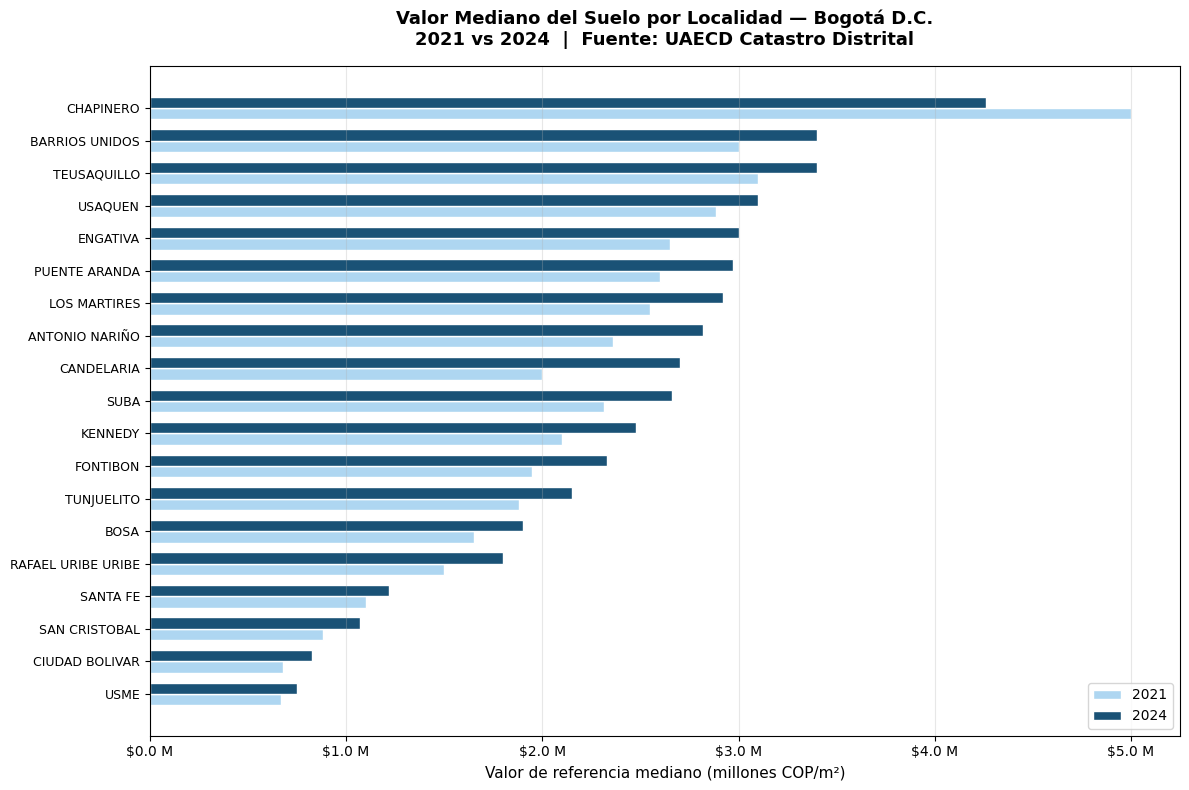

✓ Gráfica 04 guardada


In [9]:
# ── Gráfica 2: Comparativo valor absoluto 2021 vs 2024 ───────
pivot_plot = pivot.dropna(subset=["med_2021", "med_2024"]).sort_values("med_2024")

fig, ax = plt.subplots(figsize=(12, 8))
y = np.arange(len(pivot_plot))
alto = 0.35

bars_2021 = ax.barh(y - alto/2, pivot_plot["med_2021"] / 1e6,
                     alto, label="2021", color="#AED6F1", edgecolor="white")
bars_2024 = ax.barh(y + alto/2, pivot_plot["med_2024"] / 1e6,
                     alto, label="2024", color="#1A5276", edgecolor="white")

ax.set_yticks(y)
ax.set_yticklabels(pivot_plot["localidad"], fontsize=9)
ax.set_xlabel("Valor de referencia mediano (millones COP/m²)", fontsize=11)
ax.set_title("Valor Mediano del Suelo por Localidad — Bogotá D.C.\n2021 vs 2024  |  Fuente: UAECD Catastro Distrital",
             fontsize=13, fontweight="bold", pad=15)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("$%.1f M"))
ax.legend(fontsize=10)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGURES, "04_comparativo_valor_localidades.png"),
            bbox_inches="tight", dpi=150)
plt.show()
print("✓ Gráfica 04 guardada")

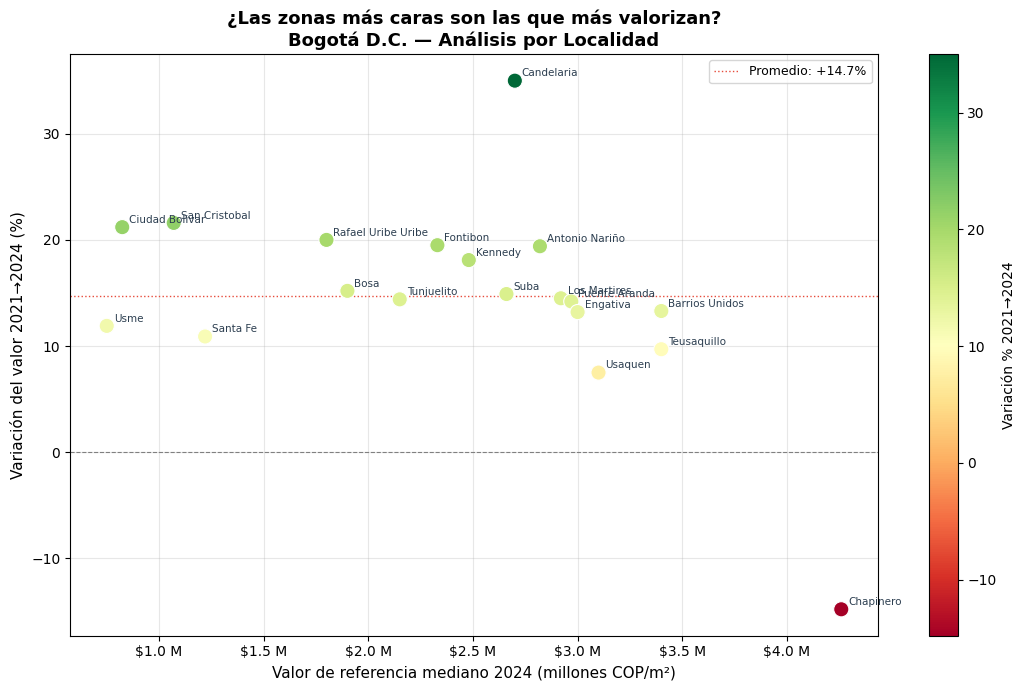

✓ Gráfica 05 guardada

✓ Las 3 gráficas están listas en reports/figures/


In [10]:
# ── Gráfica 3: Dispersión valor 2024 vs variación % ──────────
# Esta gráfica responde: ¿las zonas más caras son las que más valorizan?

fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(
    pivot["med_2024"] / 1e6,
    pivot["var_pct_2021_2024"],
    s=120, c=pivot["var_pct_2021_2024"],
    cmap="RdYlGn", edgecolors="white", linewidth=0.8, zorder=3
)

# Etiquetar cada punto
for _, row in pivot.iterrows():
    if pd.notna(row["med_2024"]) and pd.notna(row["var_pct_2021_2024"]):
        ax.annotate(
            row["localidad"].title(),
            xy=(row["med_2024"] / 1e6, row["var_pct_2021_2024"]),
            xytext=(5, 3), textcoords="offset points",
            fontsize=7.5, color="#2C3E50"
        )

# Líneas de referencia
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axhline(pivot["var_pct_2021_2024"].mean(), color="#E74C3C",
           linewidth=1, linestyle=":", label=f"Promedio: {pivot['var_pct_2021_2024'].mean():+.1f}%")

plt.colorbar(scatter, ax=ax, label="Variación % 2021→2024")
ax.set_xlabel("Valor de referencia mediano 2024 (millones COP/m²)", fontsize=11)
ax.set_ylabel("Variación del valor 2021→2024 (%)", fontsize=11)
ax.set_title("¿Las zonas más caras son las que más valorizan?\nBogotá D.C. — Análisis por Localidad",
             fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("$%.1f M"))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGURES, "05_dispersion_valor_vs_valorizacion.png"),
            bbox_inches="tight", dpi=150)
plt.show()
print("✓ Gráfica 05 guardada")
print("\n✓ Las 3 gráficas están listas en reports/figures/")